In [33]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import geopandas as gpd
from shapely.geometry import box
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


In [34]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

In [35]:
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

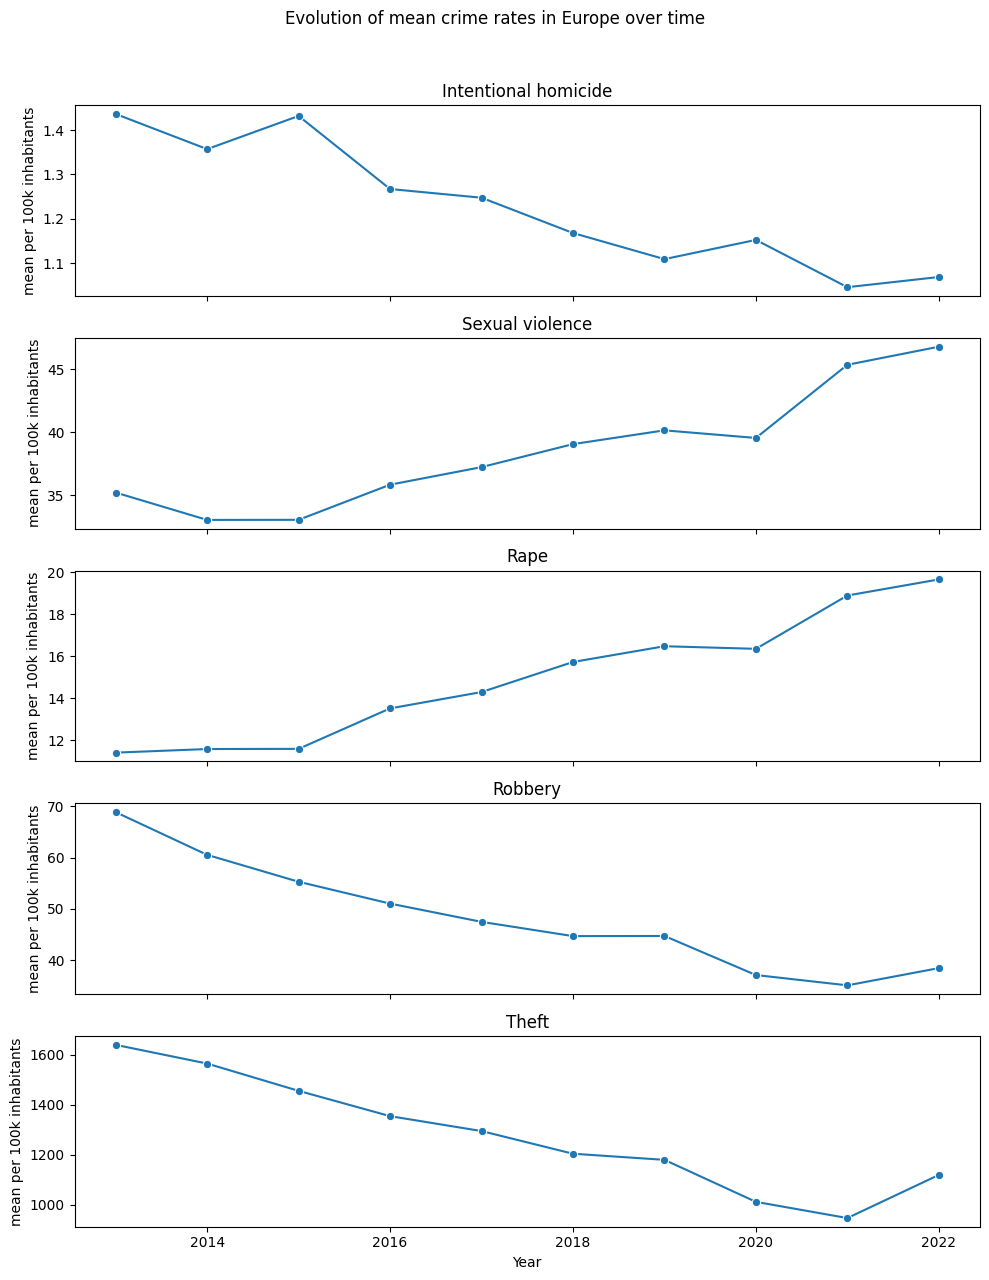

In [36]:
# Europe-wide MEAN for selected crime types by year

numeric_cols = [
    c for c in df_processed.select_dtypes(include="number").columns
    if c != "year"
 ]
df_totals = (
    df_processed
    .groupby("year")[numeric_cols]
    .mean()
    .reset_index()
 )

crime_cols = list(crime_codes.keys())
cols_for_plot = ["year"] + crime_cols
df_eu_subset = df_totals[cols_for_plot].copy()

# Long format: one row per (year, crime code)
df_eu_long = df_eu_subset.melt(
    id_vars="year",
    value_vars=crime_cols,
    var_name="iccs",
    value_name="crime_rate_per_100k"
 )

df_eu_long["crime_type"] = df_eu_long["iccs"].map(crime_codes)

# Line plots for each crime type
unique_crimes = crime_cols
n_crimes = len(unique_crimes)
fig, axes = plt.subplots(n_crimes, 1, figsize=(10, 2.5 * n_crimes), sharex=True)

if n_crimes == 1:
    axes = [axes]

for ax, iccs_code in zip(axes, unique_crimes):
    crime_name = crime_codes.get(iccs_code, iccs_code)
    data_sub = df_eu_long[df_eu_long["iccs"] == iccs_code]
    sns.lineplot(
        data=data_sub,
        x="year",
        y="crime_rate_per_100k",
        marker="o",
        ax=ax,
    )
    ax.set_title(crime_name)
    ax.set_ylabel("mean per 100k inhabitants")

axes[-1].set_xlabel("Year")
plt.suptitle("Evolution of mean crime rates in Europe over time", y=1.02)
plt.tight_layout()
plt.show()

In [37]:
df_pair = df_processed.copy()
df_pair = df_pair[df_pair["year"].isin([2013, 2022])]

pivot = (
    df_pair
    .pivot_table(index="country", columns="year", values="crime_per_100k")
    .dropna(subset=[2013, 2022])

)

crime_2013 = pivot[2013]
crime_2022 = pivot[2022]

# Shapiro-Wilk normality test on paired differences (2022 - 2013)
diff = crime_2022 - crime_2013
shapiro_stat, shapiro_p = stats.shapiro(diff)

print("Shapiro-Wilk test on paired differences (2022 - 2013)")
print(f"W-statistic: {shapiro_stat:.4f}")
print(f"P-value: {shapiro_p:.4f}")

if shapiro_p < 0.05:
    print("Data is NOT normal -> consider Wilcoxon Signed-Rank Test instead of (or in addition to) the T-Test.")
else:
    print("No evidence against normality at alpha = 0.05.")


Shapiro-Wilk test on paired differences (2022 - 2013)
W-statistic: 0.9458
P-value: 0.1696
No evidence against normality at alpha = 0.05.


In [38]:
# Paired t-test for overall crime_per_100k (2013 vs 2022) – T-test

# Assumes df_pair, pivot, crime_2013, and crime_2022 are already defined
t_stat, p_val = stats.ttest_rel(crime_2022, crime_2013)
mean_diff = (crime_2022 - crime_2013).mean()

print("Paired T-Test for crime_per_100k (2022 vs 2013)")
print(f"Number of countries used: {len(pivot)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Mean difference (2022 - 2013): {mean_diff:.4f}")

if p_val < 0.05:
    print("RESULT: SIGNIFICANT CHANGE")
else:
    print("RESULT: NO SIGNIFICANT CHANGE")

Paired T-Test for crime_per_100k (2022 vs 2013)
Number of countries used: 27
T-statistic: -5.0394
P-value: 0.0000
Mean difference (2022 - 2013): -531.4896
RESULT: SIGNIFICANT CHANGE


In [39]:
# Directional paired tests for specific crime types (2013 vs 2022)

alpha = 0.01  # 99% confidence level

codes_expect_decrease = [
    "ICCS0101",  # Intentional homicide
    "ICCS0401",  # Robbery
    "ICCS0502",  # Theft
]
codes_expect_increase = [
    "ICCS0301",   # Sexual violence
    "ICCS03011",  # Rape
]

df_pair_all = df_processed.copy()
df_pair_all = df_pair_all[df_pair_all["year"].isin([2013, 2022])]

def run_directional_paired_test(iccs_code: str, expect: str):
    label = crime_codes.get(iccs_code, iccs_code)
    sub = df_pair_all[["country", "year", iccs_code]].dropna()
    if sub.empty:
        print(f"{label} ({iccs_code}): no data available.")
        return

    pivot = (
        sub
        .pivot(index="country", columns="year", values=iccs_code)
        .dropna(subset=[2013, 2022])
)

    vals_2013 = pivot[2013]
    vals_2022 = pivot[2022]

    t_stat, p_val_two_sided = stats.ttest_rel(vals_2022, vals_2013)
    mean_diff = (vals_2022 - vals_2013).mean()

    p_val_one_sided = p_val_two_sided / 2 if p_val_two_sided is not None else None

    if expect == "decrease":
        significant = (p_val_one_sided is not None) and (p_val_one_sided < alpha) and (mean_diff < 0)
        direction_text = "expected LOWER in 2022"
    else:
        significant = (p_val_one_sided is not None) and (p_val_one_sided < alpha) and (mean_diff > 0)
        direction_text = "expected HIGHER in 2022"

    print(f"\nPaired T-Test for {label} ({iccs_code}) – {direction_text}")
    print(f"Countries used: {len(pivot)}")
    print(f"Mean 2013: {vals_2013.mean():.3f}")
    print(f"Mean 2022: {vals_2022.mean():.3f}")
    print(f"Mean diff (2022 - 2013): {mean_diff:.3f}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"Two-sided p-value: {p_val_two_sided:.4f}")
    print(f"One-sided p-value: {p_val_one_sided:.4f}")
    if significant:
        print("RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)")
    else:
        print("RESULT: NO SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)")

for code in codes_expect_decrease:
    run_directional_paired_test(code, expect="decrease")

for code in codes_expect_increase:
    run_directional_paired_test(code, expect="increase")


Paired T-Test for Intentional homicide (ICCS0101) – expected LOWER in 2022
Countries used: 27
Mean 2013: 1.436
Mean 2022: 1.069
Mean diff (2022 - 2013): -0.368
T-statistic: -2.1636
Two-sided p-value: 0.0399
One-sided p-value: 0.0199
RESULT: NO SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Robbery (ICCS0401) – expected LOWER in 2022
Countries used: 27
Mean 2013: 68.838
Mean 2022: 38.493
Mean diff (2022 - 2013): -30.345
T-statistic: -6.1500
Two-sided p-value: 0.0000
One-sided p-value: 0.0000
RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Theft (ICCS0502) – expected LOWER in 2022
Countries used: 27
Mean 2013: 1640.034
Mean 2022: 1119.765
Mean diff (2022 - 2013): -520.269
T-statistic: -4.8277
Two-sided p-value: 0.0001
One-sided p-value: 0.0000
RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Sexual violence (ICCS0301) – expected HIGHER in 2022
Countries used: 27
Mean 2013: 35.216

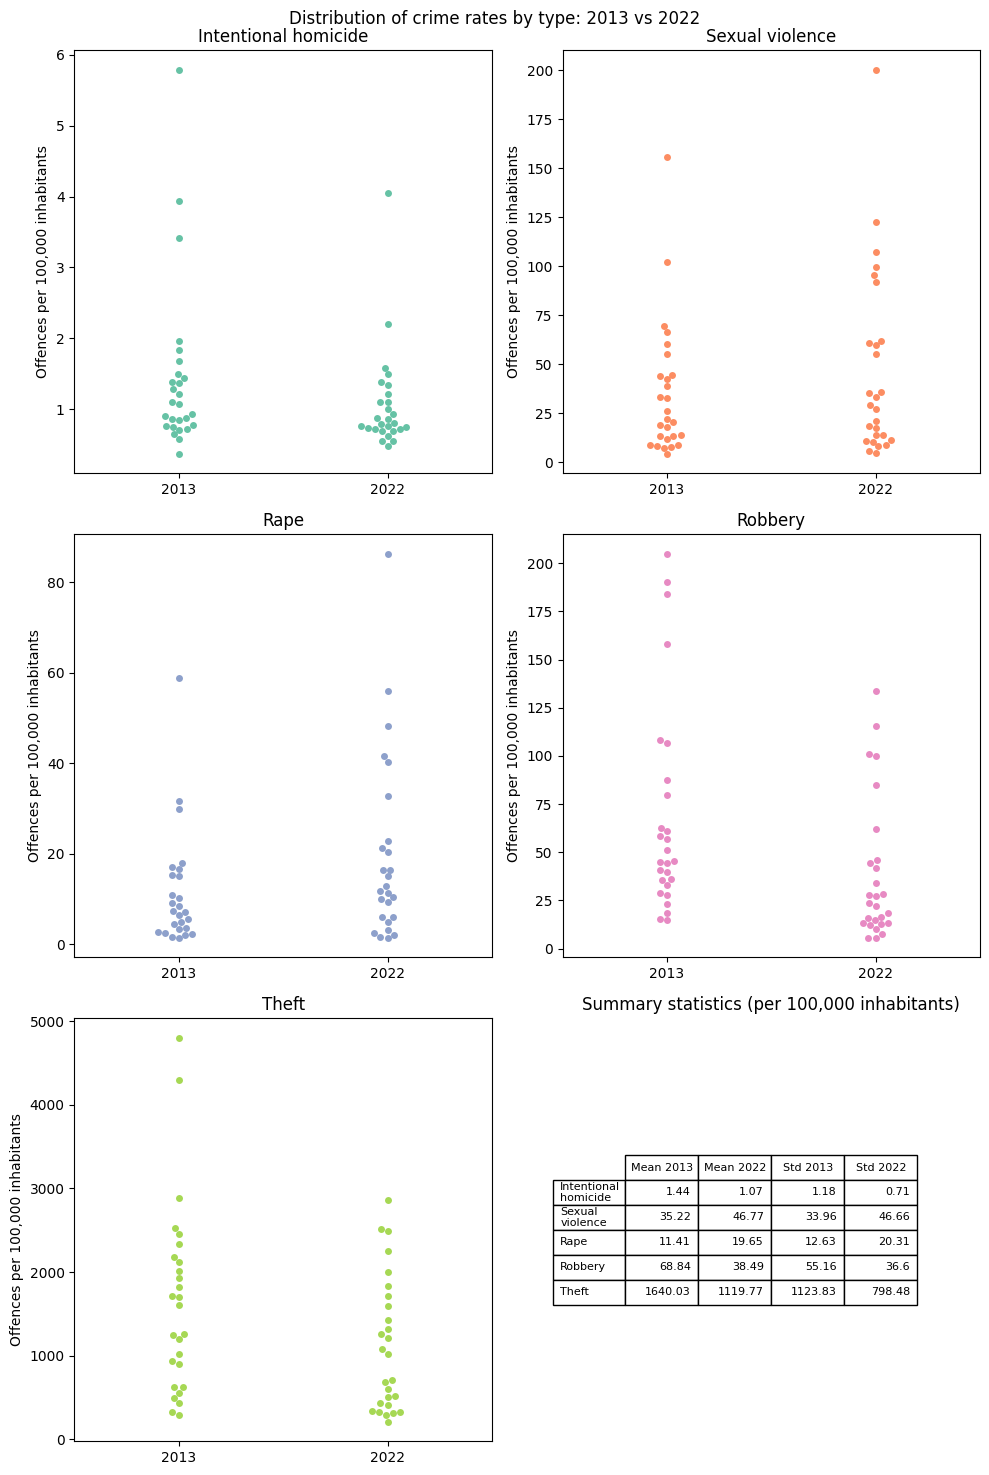

In [40]:
# Distributions of crime rates in 2013 and 2022 by type

df_box = df_processed.copy()
df_box = df_box[df_box["year"].isin([2013, 2022])]

crime_cols = list(crime_codes.keys())

df_box_long = df_box.melt(
    id_vars=["country", "year"],
    value_vars=crime_cols,
    var_name="iccs",
    value_name="crime_rate_per_100k"
 )

df_box_long["crime_type"] = df_box_long["iccs"].map(crime_codes)

crime_order = [crime_codes[c] for c in crime_cols]
colors = sns.color_palette("Set2", len(crime_order))

fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharex=False)
axes_flat = axes.flatten()

# First 5 subplots: swarmplots per crime type
for i, crime_name in enumerate(crime_order):
    ax = axes_flat[i]
    data_sub = df_box_long[df_box_long["crime_type"] == crime_name]
    sns.swarmplot(
        data=data_sub,
        x="year",
        y="crime_rate_per_100k",
        ax=ax,
        color=colors[i],
    )
    ax.set_title(crime_name)
    ax.set_xlabel("")
    ax.set_ylabel("Offences per 100,000 inhabitants")

# Last subplot: summary statistics table
table_ax = axes_flat[-1]
table_ax.axis("off")

stats_rows = []
for crime_name in crime_order:
    data_2013 = df_box_long[(df_box_long["crime_type"] == crime_name) & (df_box_long["year"] == 2013)]["crime_rate_per_100k"]
    data_2022 = df_box_long[(df_box_long["crime_type"] == crime_name) & (df_box_long["year"] == 2022)]["crime_rate_per_100k"]
    stats_rows.append({
        "Crime": crime_name,
        "Mean 2013": data_2013.mean(),
        "Mean 2022": data_2022.mean(),
        "Std 2013": data_2013.std(),
        "Std 2022": data_2022.std(),
    })

df_stats = pd.DataFrame(stats_rows)
df_stats_round = df_stats.copy()
df_stats_round.iloc[:, 1:] = df_stats_round.iloc[:, 1:].round(2)

col_labels = ["Mean 2013", "Mean 2022", "Std 2013", "Std 2022"]

row_labels = df_stats_round["Crime"].replace({
    "Intentional homicide": "Intentional\nhomicide",
    "Sexual violence": "Sexual\nviolence",}
)

table = table_ax.table(
    cellText=df_stats_round.iloc[:, 1:].values,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(0.7, 1.2)
table_ax.set_title("Summary statistics (per 100,000 inhabitants)")

plt.suptitle("Distribution of crime rates by type: 2013 vs 2022", y=0.98)
plt.tight_layout()
plt.show()

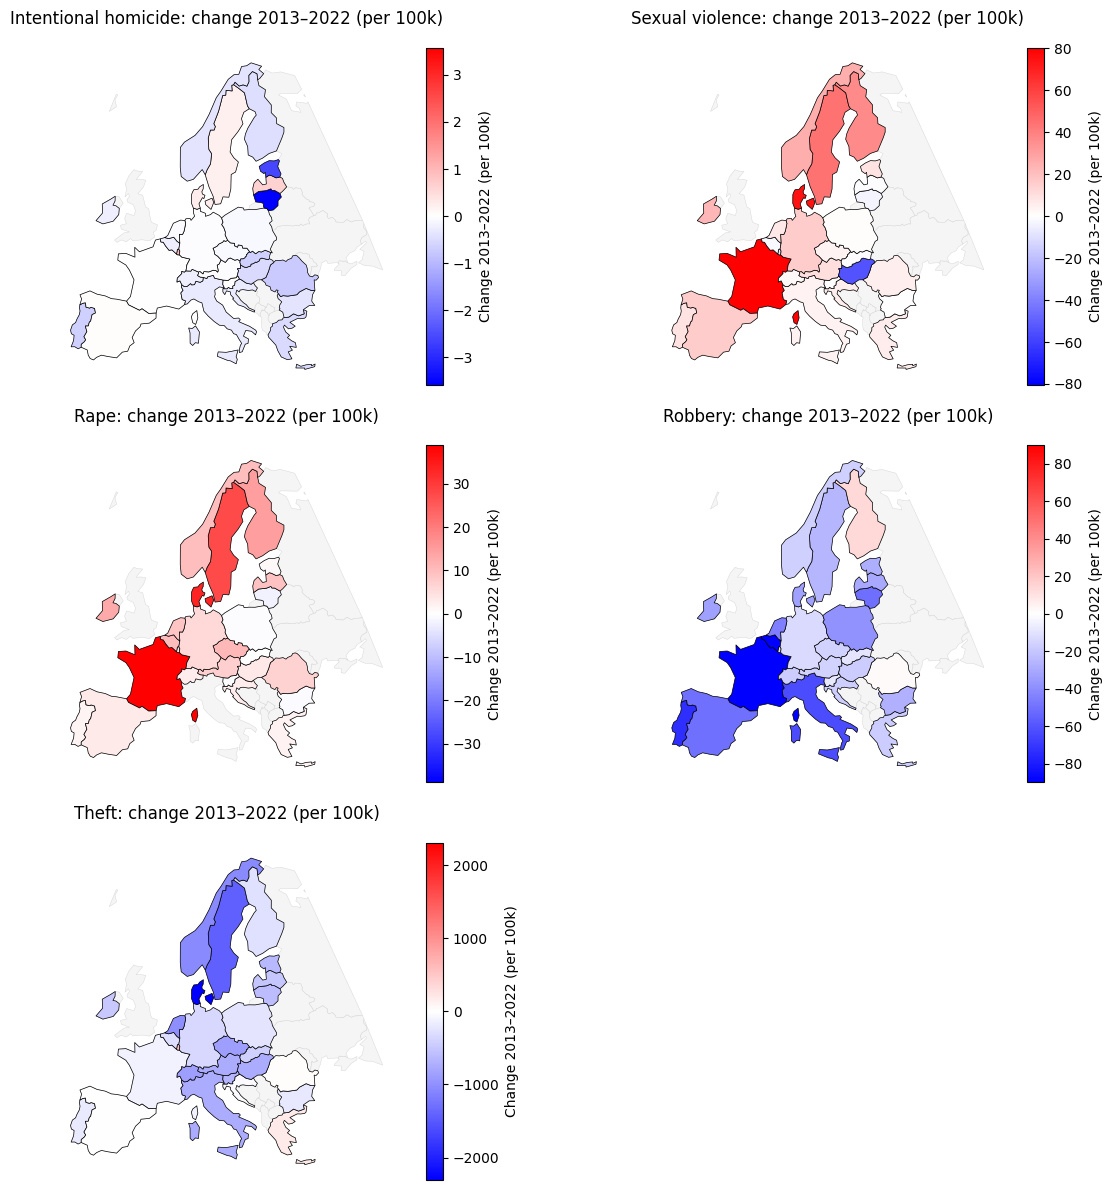

In [41]:
# Europe maps: absolute decade change per crime (2013 → 2022, per 100k)

crime_cols = list(crime_codes.keys())

start_year = 2013
end_year = 2022
df_decade = df_processed[df_processed["year"].isin([start_year, end_year])].copy()

pivot = df_decade.pivot_table(index="country", columns="year", values=crime_cols)

vals_start = pivot.xs(start_year, level="year", axis=1)
vals_end = pivot.xs(end_year, level="year", axis=1)

delta = vals_end - vals_start

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
europe = world[world["CONTINENT"] == "Europe"].copy()

europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

europe_laea = europe.to_crs(epsg=3035)

bwr_cmap = LinearSegmentedColormap.from_list("blue_white_red", ["blue", "white", "red"])

# Create a single figure with a 3x2 grid of subplots
n_crimes = len(crime_cols)
n_rows, n_cols = 3, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12))
axes_flat = axes.flatten()

for idx, (iccs_code, ax) in enumerate(zip(crime_cols, axes_flat)):
    crime_name = crime_codes.get(iccs_code, iccs_code)
    df_delta = delta[[iccs_code]].rename(columns={iccs_code: "delta_per_100k"}).reset_index()

    gdf = europe_laea.merge(df_delta, left_on="NAME", right_on="country", how="left")

    max_abs = np.nanmax(np.abs(gdf["delta_per_100k"]))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0

    # Base map
    gdf.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)
    # Choropleth of changes
    gdf.dropna(subset=["delta_per_100k"]).plot(
        column="delta_per_100k",
        ax=ax,
        cmap=bwr_cmap,
        vmin=-max_abs,
        vmax=max_abs,
        edgecolor="black",
        linewidth=0.5,
        legend=True,
        legend_kwds={"label": "Change {}–{} (per 100k)".format(start_year, end_year)},
)
    ax.set_title(f"{crime_name}: change {start_year}–{end_year} (per 100k)")
    ax.set_axis_off()

# Hide any unused subplot (the 6th panel if only 5 crimes)
for j in range(n_crimes, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
df_processed[(df_processed['country'] == 'Italy') & (df_processed['year'] == 2013)]

,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0301,ICCS03011,ICCS0401,ICCS0502,crime_per_100k
150,IT,2013,25720.0,60277309.0,42.669456,Italy,0.85,7.52,NaN,106.84,2183.71,2298.92
